C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

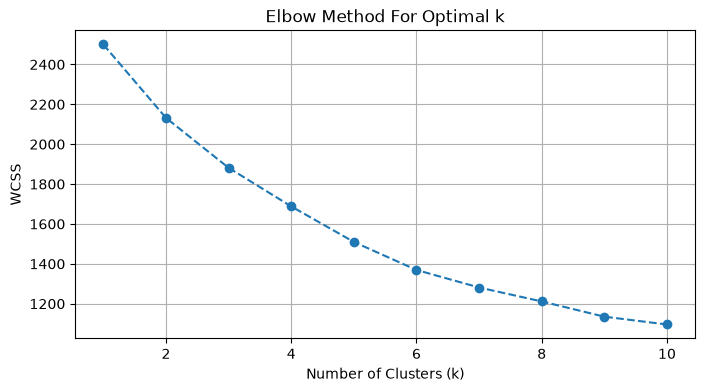

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Silhouette Score for k=4: 0.147

--- Cluster Means ---
   Cluster        Age  AnnualIncome_k  SpendingScore  Recency_Days  \
0        0  52.560000       70.653333      50.300000    207.193333   
1        1  35.056911       69.089431      79.097561    162.674797   
2        2  55.957627       78.313559      32.669492    117.601695   
3        3  30.376147       95.935780      29.752294    221.724771   

   PurchaseFrequency  
0          38.920000  
1          20.934959  
2          13.881356  
3          23.247706  


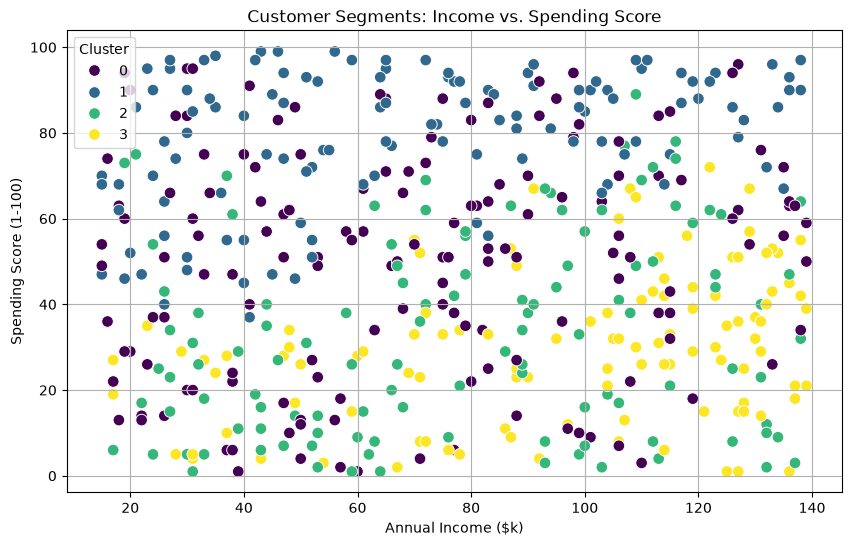

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==========================================
# 1. GENERATE SYNTHETIC CUSTOMER DATA
# ==========================================
np.random.seed(42)
n_customers = 500

data = pd.DataFrame({
    'CustomerID': np.arange(1001, 1001 + n_customers),
    'Age': np.random.randint(18, 70, size=n_customers),
    'AnnualIncome_k': np.random.randint(15, 140, size=n_customers),
    'SpendingScore': np.random.randint(1, 100, size=n_customers),
    'Recency_Days': np.random.randint(1, 365, size=n_customers),
    'PurchaseFrequency': np.random.randint(1, 50, size=n_customers)
})

# ==========================================
# 2. PREPROCESSING & FEATURE SCALING
# ==========================================
# Select numerical features for clustering
features = ['Age', 'AnnualIncome_k', 'SpendingScore', 'Recency_Days', 'PurchaseFrequency']
X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. DETERMINE OPTIMAL CLUSTERS (ELBOW METHOD)
# ==========================================
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# ==========================================
# 4. TRAIN K-MEANS MODEL
# ==========================================
optimal_k = 4  # Set based on elbow plot evaluation
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
data['Cluster'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, data['Cluster'])
print(f"Silhouette Score for k={optimal_k}: {score:.3f}")

# ==========================================
# 5. SEGMENT PROFILING & ANALYSIS
# ==========================================
cluster_summary = data.groupby('Cluster')[features].mean().reset_index()
print("\n--- Cluster Means ---")
print(cluster_summary)

# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data, 
    x='AnnualIncome_k', 
    y='SpendingScore', 
    hue='Cluster', 
    palette='viridis', 
    s=70
)
plt.title('Customer Segments: Income vs. Spending Score')
plt.xlabel('Annual Income ($k)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()

# Export results to CSV for Power BI / Tableau visualization
# data.to_csv('customer_segmentation_results.csv', index=False)